In [1]:
import torch
import torch.nn as nn

In [2]:
import torch.nn.functional as F

In [5]:
class Model(nn.Module):
    
    def __init__(self,in_features=4,h1=8,h2=9,out_features=3):
        super().__init__() # activates inherited library
        self.fc1 = nn.Linear(in_features,h1)
        self.fc2 = nn.Linear(h1,h2)
        self.out = nn.Linear(h2,out_features)
        # Input Layer --> h1 --> h2 --> Output layer (3 classes)
        
    
    def forward(self,x):
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.out(x))
        
        return x

In [7]:
torch.manual_seed(32)
model = Model()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
df = pd.read_csv('../Data/iris.csv')

In [10]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [11]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0
149,5.9,3.0,5.1,1.8,2.0


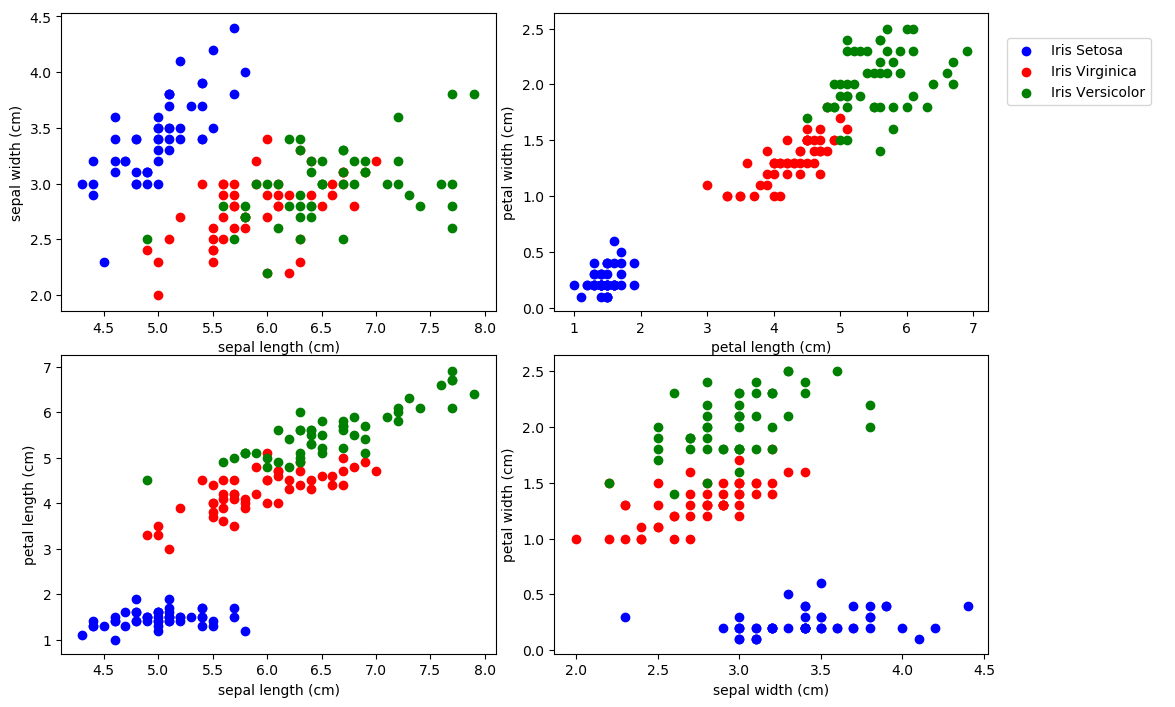

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,7))
fig.tight_layout()

plots = [(0,1),(2,3),(0,2),(1,3)]
colors = ['b', 'r', 'g']
labels = ['Iris Setosa','Iris Virginica','Iris Versicolor']

for i, ax in enumerate(axes.flat):
    for j in range(3):
        x = df.columns[plots[i][0]]
        y = df.columns[plots[i][1]]
        ax.scatter(df[df['target']==j][x], df[df['target']==j][y], color=colors[j])
        ax.set(xlabel=x, ylabel=y)

fig.legend(labels=labels, loc=3, bbox_to_anchor=(1.0,0.85))
plt.show()


In [14]:
from torch.utils.data import TensorDataset, DataLoader

data = df.drop('target',axis=1).values
labels = df['target'].values

iris = TensorDataset(torch.FloatTensor(data),torch.LongTensor(labels))

In [17]:
iris_loader = DataLoader(iris, batch_size=50, shuffle=True)

In [18]:
for batch in iris_loader:
    print(batch)

[tensor([[6.3000, 2.3000, 4.4000, 1.3000],
        [6.0000, 3.0000, 4.8000, 1.8000],
        [6.6000, 3.0000, 4.4000, 1.4000],
        [5.4000, 3.9000, 1.3000, 0.4000],
        [5.8000, 4.0000, 1.2000, 0.2000],
        [5.0000, 3.4000, 1.5000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [6.0000, 2.7000, 5.1000, 1.6000],
        [6.3000, 2.8000, 5.1000, 1.5000],
        [6.5000, 3.0000, 5.8000, 2.2000],
        [5.5000, 4.2000, 1.4000, 0.2000],
        [5.9000, 3.0000, 5.1000, 1.8000],
        [6.3000, 3.3000, 4.7000, 1.6000],
        [6.0000, 2.9000, 4.5000, 1.5000],
        [6.8000, 2.8000, 4.8000, 1.4000],
        [4.8000, 3.0000, 1.4000, 0.1000],
        [6.1000, 2.8000, 4.7000, 1.2000],
        [6.4000, 3.2000, 5.3000, 2.3000],
        [4.6000, 3.4000, 1.4000, 0.3000],
        [5.7000, 4.4000, 1.5000, 0.4000],
        [5.6000, 3.0000, 4.5000, 1.5000],
        [7.1000, 3.0000, 5.9000, 2.1000],
        [5.8000, 2.7000, 3.9000, 1.2000],
        [7.9000, 3.8000, 6.4000, 